In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [ ]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [4]:
# Distribution of the binary response variable
print('Potability class distribution:')
print(df['Potability'].value_counts())
print(f'Class balance: {df["Potability"].mean():.1%} potable')

# Count and proportion of missing values per feature
print('\nMissing values per feature:')
print(df.isnull().sum())

# Summary statistics to understand the scale and spread of each feature
df.describe()

Potability class distribution:
Potability
0    1998
1    1278
Name: count, dtype: int64
Class balance: 39.0% potable

Missing values per feature:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [ ]:
# Impute missing values with each column's median
df_clean = df.fillna(df.median())

# Verify no missing values remain
print(f'Missing values after imputation: {df_clean.isnull().sum().sum()}')

# Separate features from the binary response variable
X = df_clean.drop('Potability', axis=1)
y = df_clean['Potability']

# 70/30 stratified split — stratify=y preserves the class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples : {X_test.shape[0]}')

Missing values after imputation: 0
Training samples : 2293
Test samples : 983


In [6]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [7]:
# Fit an unconstrained decision tree, no limit on depth or leaf size
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

# Report the tree's full depth, a proxy for model complexity
tree_depth = dt_unpruned.get_depth()

# Accuracy on training data and held-out test data
dt_unpruned_acc_train = accuracy_score(y_train, dt_unpruned.predict(X_train))
dt_unpruned_acc_test  = accuracy_score(y_test,  dt_unpruned.predict(X_test))

print(f'Tree depth: {tree_depth}')
print(f'Training accuracy: {dt_unpruned_acc_train:.3f}')
print(f'Test accuracy: {dt_unpruned_acc_test:.3f}')

Tree depth: 33
Training accuracy: 1.000
Test accuracy: 0.581


In [8]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

The training accuracy is perfect at 100% but the test accuracy is only 58.1%, a gap of 42 percentage points.

This means the model is overfitting. The tree grew 33 levels deep, which means it kept splitting the data over and over until it memorized every single training sample. It learned the training data by heart. When it sees brand new water samples, it struggles because it never actually learned the real patterns, it just memorized the examples it was trained on. A 58% accuracy on new data is barely better than randomly guessing.

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

Optimal max_depth (5-fold CV): 7 (CV accuracy: 0.639)


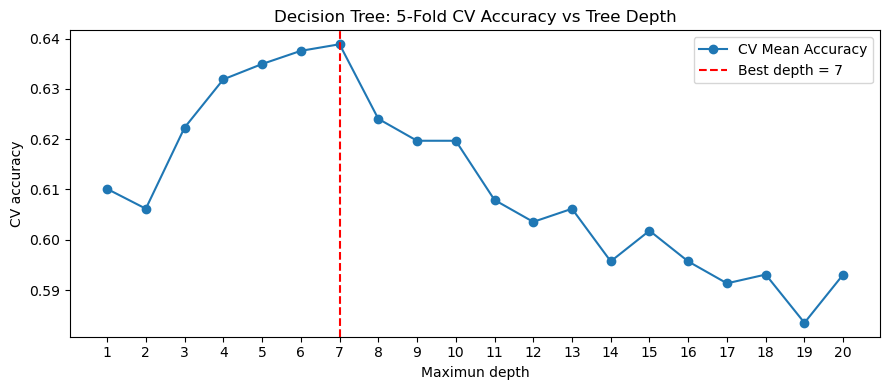

In [9]:
depths = range(1, 21) # candidate max_depth values from 1 to 20
cv_accs = []

# Perform 5-fold cross-validation on training data for each candidate depth
for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
    cv_accs.append(scores.mean())

cv_accs = np.array(cv_accs)

# The depth with the highest mean CV accuracy is selected as optimal
optimal_depth = list(depths)[np.argmax(cv_accs)]
print(f'Optimal max_depth (5-fold CV): {optimal_depth} (CV accuracy: {cv_accs.max():.3f})')

plt.figure(figsize=(9, 4))
plt.plot(list(depths), cv_accs, label='CV Mean Accuracy', marker='o')
plt.axvline(optimal_depth, color='red', linestyle='--', label=f'Best depth = {optimal_depth}')
plt.xlabel('Maximun depth')
plt.ylabel('CV accuracy')
plt.xticks(list(depths))
plt.title('Decision Tree: 5-Fold CV Accuracy vs Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

Cross validation found the optimal depth to be 7.

Looking at the plot, accuracy keeps improving as we allow the tree to grow deeper, up until depth 7. After that it starts dropping. A depth of 7 is good, deep enough to pick up real patterns in the water chemistry, but shallow enough to avoid memorizing the training data. Beyond depth 7, the extra splits do more harm than good. In simple terms, the tree is allowed to ask 7 yes/no questions before making its final call on whether the water is potable or not.

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [11]:
# Refit the decision tree using the cross validated optimal depth
dt_opt = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
dt_opt.fit(X_train, y_train)

# Evaluate on the held-out test set
acc_dt = accuracy_score(y_test, dt_opt.predict(X_test))
print(f'Tuned Decision Tree Test Accuracy (max_depth={optimal_depth}): {acc_dt:.3f}')

Tuned Decision Tree Test Accuracy (max_depth=7): 0.646


In [12]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree imrpove compared to your untuned tree? If so, why do you think it improved?**

Yes, the accuracy improved from 58.1% to 64.6% after tuning.

The untuned tree grew 33 levels deep and basically memorized the training data, which is why it failed on new samples. By cutting the depth down to 7, we stopped the tree from going too deep and picking up noise. It now only learns the most important patterns in the data, which makes it much better at handling water samples it has never seen before.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

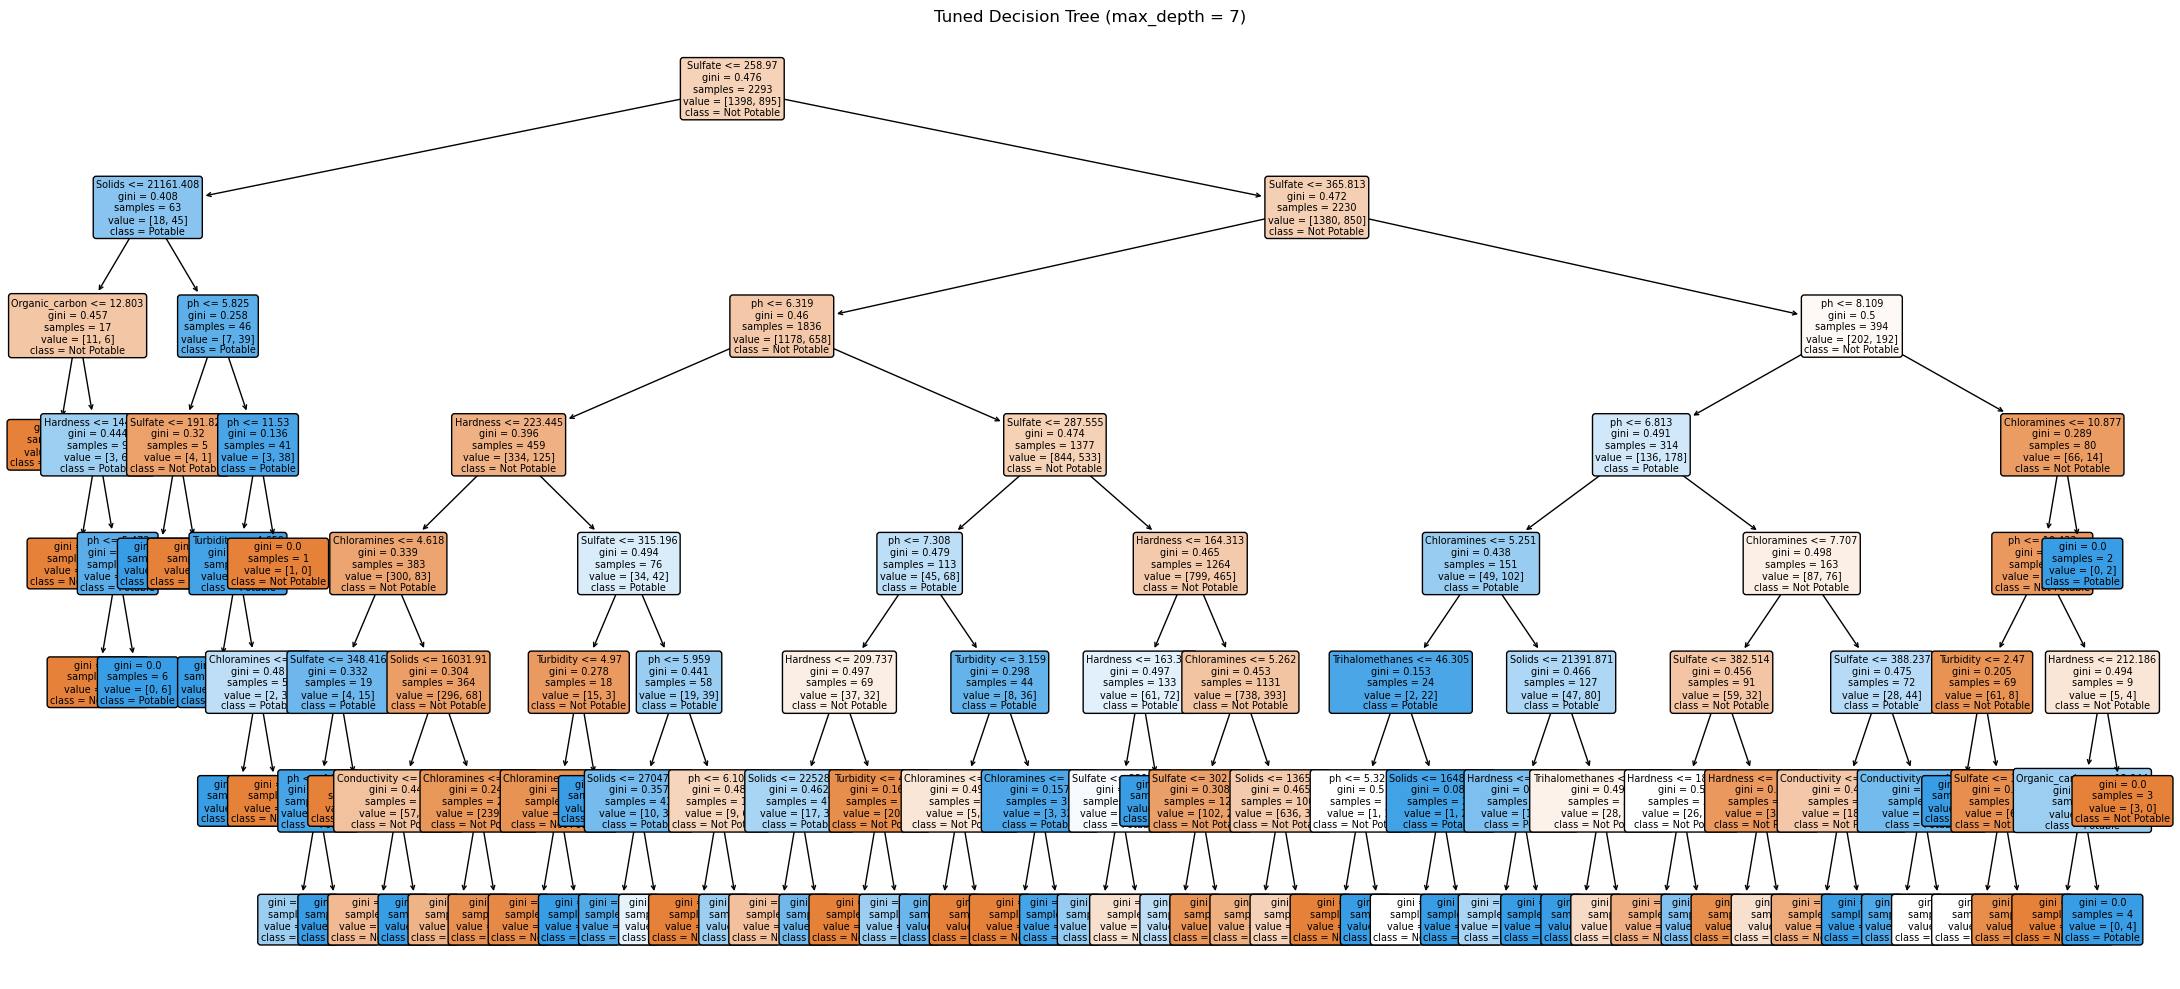

In [13]:
from sklearn.tree import plot_tree

# Plot the tuned tree, filled nodes show the majority class at each split
plt.figure(figsize=(22, 10))
plot_tree(
    dt_opt,
    feature_names=X_train.columns.tolist(),
    class_names=['Not Potable', 'Potable'],
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title(f'Tuned Decision Tree (max_depth = {optimal_depth})')
plt.tight_layout()
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

The root node splits on Sulfate ≤ 258.97.

This tells us that Sulfate is the most useful feature for separating potable from non-potable water. The tree picked it first out of all nine features. Water samples with sulfate below 258.97 go left, and those above go right.

The Gini impurity at the root is 0.476, which is close to the maximum of 0.5, meaning the training data at the top is almost evenly split between potable and non-potable. After the first split, the left branch drops to 0.408 and the right branch to 0.472, both lower than the root, meaning each group is now slightly more pure than before. The second level then splits on Solids and Sulfate again, continuing to separate the two classes further.

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [17]:
# Train a random forest with 200 trees

# Each tree sees a random subset of features at every split, reducing overfitting
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Evaluate on the test set
acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f'Random Forest Test Accuracy (n_estimators=200): {acc_rf:.3f}')

Random Forest Test Accuracy (n_estimators=200): 0.664


In [15]:
grader.check("q5")

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

The Random Forest performed better with 66.4% accuracy compared to the Decision Tree's 64.6%.

The reason is simple. A single decision tree makes one set of decisions and sticks with them. If it makes a bad split early on, every prediction after that is affected. The Random Forest trains 200 different trees and lets them all vote on the answer. When one tree gets it wrong, the other 199 can outvote it.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

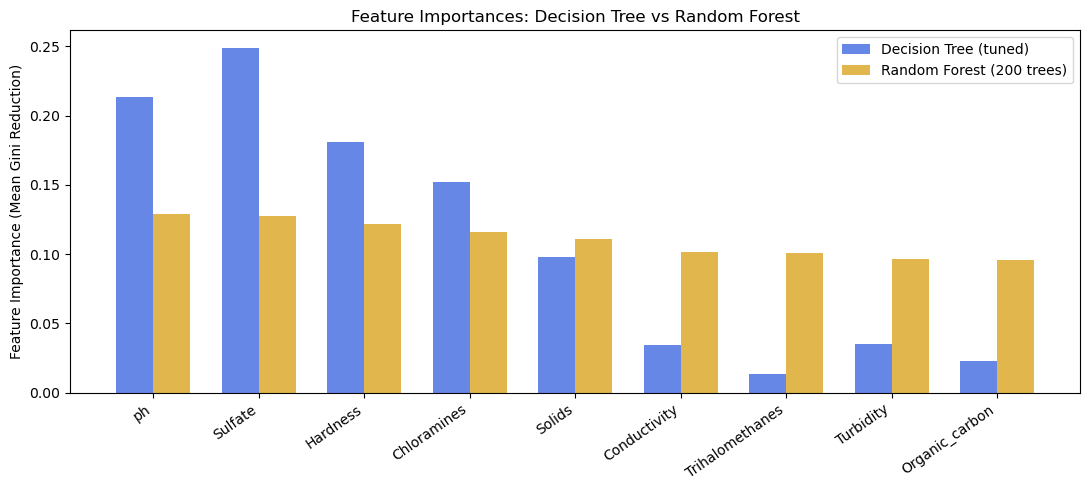

In [19]:
# Feature importances, how much each feature reduces impurity across all splits
feat_names = X_train.columns.tolist()
dt_importances = dt_opt.feature_importances_
rf_importances = rf.feature_importances_

# Sort features by random forest importance, highest first
sorted_idx = np.argsort(rf_importances)[::-1]

x = np.arange(len(feat_names))
w = 0.35  # bar width

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, dt_importances[sorted_idx], w,
       label='Decision Tree (tuned)', color='royalblue', alpha=0.8)
ax.bar(x + w/2, rf_importances[sorted_idx], w,
       label='Random Forest (200 trees)', color='goldenrod', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([feat_names[i] for i in sorted_idx], rotation=35, ha='right')
ax.set_ylabel('Feature Importance (Mean Gini Reduction)')
ax.set_title('Feature Importances: Decision Tree vs Random Forest')
ax.legend()
plt.tight_layout()
plt.show()

> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

The two models partly agree but differ in how they spread importance across features.

The decision tree puts most of its weight on just four features (Sulfate, pH, Hardness and Chloramines) and barely uses the rest. The random forest spreads the importance much more evenly across all nine features.

A single tree is less reliable because whichever feature gets picked first gets a lot of credit, just for being first. The random forest uses 200 trees, each looking at different random features, so no single feature gets unfairly boosted. The result is a more balanced and honest picture.

pH comes out as the most important feature in the random forest. This makes sense in the real world, water that is too acidic or too alkaline is unsafe to drink, and pH is one of the first things tested when checking water quality.

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

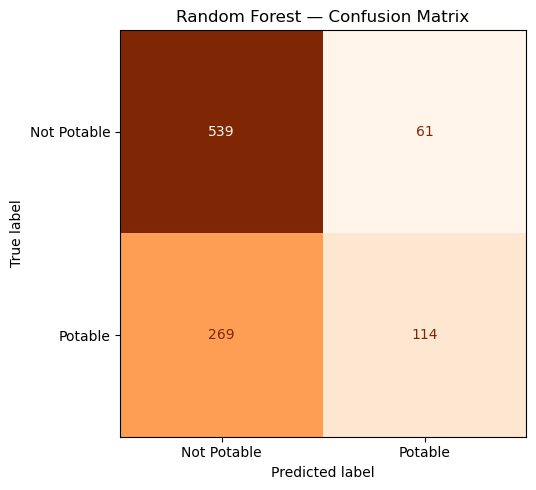

In [ ]:
# Generate predictions from the random forest on the test set
y_pred_rf = rf.predict(X_test)

# Compute confusion matrix and display with human-readable class labels
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Potable', 'Potable']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Random Forest: Confusion Matrix')
plt.tight_layout()
plt.show()

<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

From the confusion matrix:

- **True Negatives = 539** The model correctly flagged 539 water samples as not safe to drink.

- **False Positives = 61** The model said 61 unsafe water samples were safe to drink. These are the most dangerous mistakes. People could get sick drinking this water.

- **False Negatives = 269** The model said 269 safe water samples were not safe to drink. These are wrong but not dangerous, just wasted water that could have been used.

- **True Positives = 114** The model correctly identified 114 water samples as safe to drink.

The model is much better at spotting bad water than approving good water. The 61 false positives are the biggest concern here because they represent unsafe water that slipped through as safe.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

                    Model  Test Accuracy
            Unpruned Tree          0.581
     Tuned Tree (depth=7)          0.646
Random Forest (200 trees)          0.664


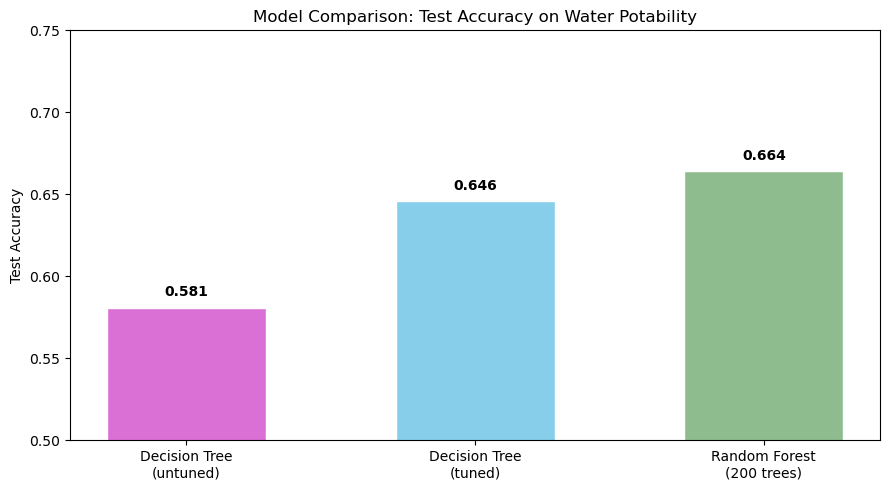

In [23]:
# Collect test accuracies for all three models
model_names = ['Decision Tree\n(untuned)', 'Decision Tree\n(tuned)', 'Random Forest\n(200 trees)']
test_accs = [dt_unpruned_acc_test, acc_dt, acc_rf]
colors = ['orchid', 'skyblue', 'darkseagreen']

# Summary table
comparison_df = pd.DataFrame({
    'Model': ['Unpruned Tree', 'Tuned Tree (depth=7)', 'Random Forest (200 trees)'],
    'Test Accuracy': [round(dt_unpruned_acc_test, 3), round(acc_dt, 3), round(acc_rf, 3)]
})
print(comparison_df.to_string(index=False))

# Bar chart comparing all three models
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, test_accs, color=colors, edgecolor='white', width=0.55)
ax.set_ylim(0.5, 0.75)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison: Test Accuracy on Water Potability')

# Annotate each bar with its accuracy value
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


The Random Forest achieved the highest test accuracy at 66.4%.

Tuning improved accuracy from 58.1% to 64.6%, a jump of 6.5 percentage points just from limiting how deep the tree could grow.

This shows the untuned (unpruned) tree was badly overfitting. It grew 33 levels deep and memorized the training data instead of learning real patterns. Cutting it back to 7 levels forced it to focus only on the most useful patterns, which made it much better at predicting new water samples. The Random Forest pushed it even further by combining 200 trees and averaging out their mistakes.

---

Run the cell below to receive credit for autograded questions. 

In [16]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results:
    q5 - 1 result:
        ✅ Test case passed

    q5 - 2 result:
        ❌ Test case failed
        Trying:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Expecting nothing
        **********************************************************************
        Line 1, in q5 1
        Failed example:
            assert np.isclose(acc_rf, 0.6612, atol=0.001)
        Exception raised:
            Traceback (most recent call last):
              File "/opt/anaconda3/envs/eds232-env/lib/python3.10/doctest.py", line 1350, in __run
                exec(compile(example.source, filename, "single",
              File "<doctest q5 1[0]>", line 1, in <module>
                assert np.isclose(acc_rf, 0.6612, atol=0.001)
            AssertionError